In [2]:
#CSSPX
import numpy as np
import pandas as pd 
import yfinance as yf
from datetime import date

In [3]:
#import data of last 5 years 
CSPX_L = yf.download("CSPX.L", start = "2021-01-01" , end = date.today())

[*********************100%***********************]  1 of 1 completed


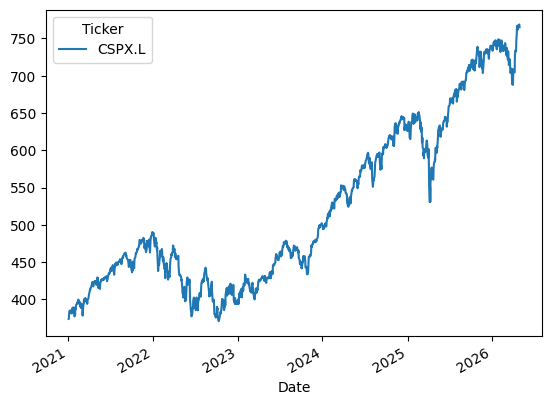

In [4]:
#CSSPX
prezzidichiusura = CSPX_L["Close"]
import matplotlib.pyplot as plt
plotprezzi = prezzidichiusura.plot()

<Axes: xlabel='Date'>

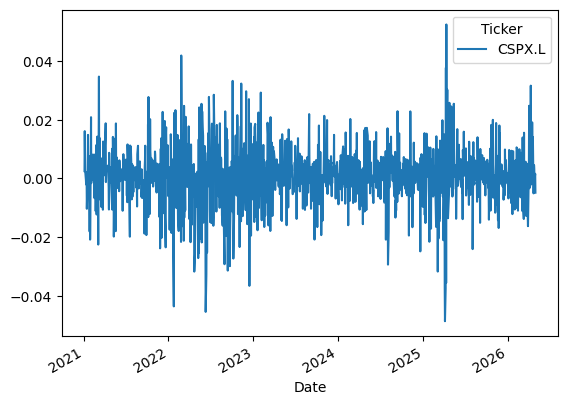

In [5]:
#SIMPLE CUMULATIVE RETURN 
#.iloc[0] gets the first value, .iloc[-1] gets the last one 
prezzo_iniziale = prezzidichiusura.iloc[0]
prezzo_finale = prezzidichiusura.iloc[-1]

#lets apply the simple cumulative returns formula 
rendimentosemplicecumulato = ((prezzo_finale - prezzo_iniziale)/ prezzo_iniziale ) *100 #in percentage 

rendimentosemplicecumulato #Significa che in 5 anni totali la crescita è stata 22% 
#se avessi investito 100€ 5 anni fà ora avrei 122€

#SIMPLE RETURN AUTO
returns = prezzidichiusura.pct_change().dropna() # prezzi ripuliti da NA 
returns.plot() #rappresenta la volatilità giornaliera
#Se la nuvola blu è compresa tra 0.01 e -0.01, il mercato è calmo altrienti c'è incertezza 

In [6]:
# Il giorno del peggior crollo in 5 anni
data_peggiore = returns.idxmin()
valore_peggiore = returns.min()

# Il giorno del miglior rialzo in 5 anni
data_migliore = returns.idxmax()
valore_migliore = returns.max()

In [7]:
data_peggiore

Ticker
CSPX.L   2025-04-04
dtype: datetime64[s]

In [8]:
data_migliore

Ticker
CSPX.L   2025-04-10
dtype: datetime64[s]

In [9]:
valore_peggiore = returns.min()
valore_peggiore #se avessi 100€ investiti avrei perso 4€

Ticker
CSPX.L   -0.048571
dtype: float64

In [10]:
valore_migliore = returns.max()
valore_migliore #se avessi 100€ investiti avrei guadagnato 6€

Ticker
CSPX.L    0.052427
dtype: float64

In [11]:
# CSPX.L è la versione quotata a Londra in USD
ticker1 = yf.download(["CSPX.L", "^SP500TR"], start="2021-01-01")["Close"]#al posto di ^GSPC uso ^SP500TR perchè quello di prima non include lo stacco dei dividendi 

[*********************100%***********************]  2 of 2 completed


In [12]:
tickerpulito = ticker1.dropna()

In [13]:
#Normalizza (CONFRONTO RENDIMENTI)
# (Prezzo Corrente / Prezzo Iniziale) - 1
returns_data = (ticker1 / ticker1.iloc[0] - 1) * 100 #ora ottengo grafici che partono da 0 e rendono quindi possibile la comparazione grafica 

<Axes: xlabel='Date'>

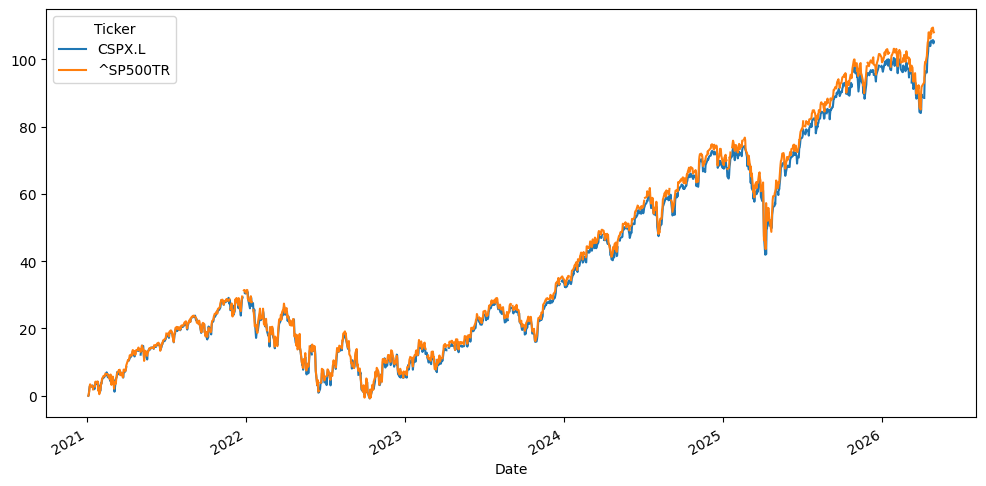

In [14]:
returns_data.plot(figsize=(12, 6))

In [15]:
#Tracking Difference: Misura la differenza tra la performance dell'ETF e quella dell'indice che replica. Deve essere il più vicino possibile allo zero o negativa (l'ETF performa meglio dell'indice al netto dei costi).
diff_finale = returns_data['CSPX.L'].iloc[-1] - returns_data['^SP500TR'].iloc[-1]
print(f"Tracking Difference: {diff_finale:.2f}%")
#se il Tracking Difference risulta essere addirittura negativo , significa che l'ETF ha sovraperformato l'indice di rifermineto 

Tracking Difference: -2.71%


<Axes: xlabel='Date'>

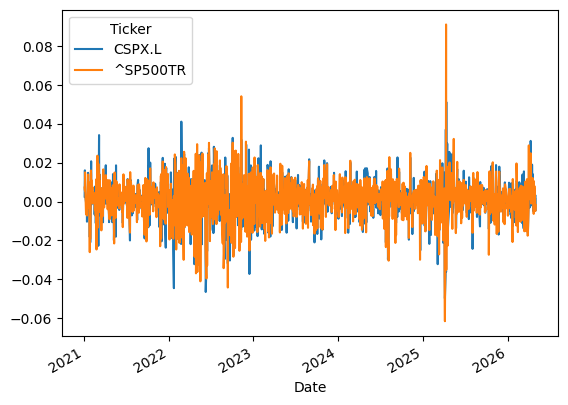

In [16]:
#Andiamo a condurre qualche test statistico usando statsmodels :
#step 1 : meglio lavorare con i rendimenti logaritmici per via delle loro proprietà 
prezzi_ieri = tickerpulito.shift(1)
#ora vediamo quanto il prezzo è variato 
variazione = tickerpulito / prezzi_ieri
#ora possiamo applicare il logaritmo 
rendimenti_log = np.log(variazione)
#siccome la prima riga restituisce sempre una righa vuota ,eliminiamo il NA grazie a : dropna()
rendimenti_log = rendimenti_log.dropna()
rendimenti_log
rendimenti_log.plot()

In [17]:
#step 2 : REGRESSIONE LINEARE 
#voglio capire quanto la mia variabile dipendente Y(ETF = CSPX.L) dipende dall'indice di mercato/var. indipendente (INDICE = ^SP500TR)
# formula : Rendimento_ETF = alpha + Beta * Rendimento_INDICE + error 
#dove alpha = intercetta 
#     beta = coefficente angolare (ovvero la pendenza della retta) ; se Beta = 1 -> l'etf si muove esattamente come il mercato 
#                                                                       Beta > 1 -> se mercato fa 1% ,l'etf fa più del 1% (l'etf esagera)
#                                                                       Beta < 1 -> l'etf è difensivo ,cioè non risente tanto del mercato 
#     error(€) = è a parte di movimento dell'ETF che il mercato non riesce a catturare 

# per trovare la retta -> OLS Method (Ordinary Least Square)

In [18]:
pip install statsmodels # per il modello è necessario scaricare questa libreria 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import statsmodels.api as sm

In [20]:
pip list

Package                   Version
------------------------- ------------
anyio                     4.12.1
appnope                   0.1.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.6
comm                      0.2.3
contourpy                 1.3.3
curl_cffi                 0.13.0
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.62.1
fqdn                      1.5.1
frozendict                2.4.7
h11                       0.16.0
httpcore                  1.0.9
httpx          

In [21]:
#Prepariamo i data per la regressione :
Y = rendimenti_log['CSPX.L'] #la mia variabile dipendente (ETF)
X = rendimenti_log['^SP500TR'] # la mia variabile indipendente 

In [22]:
X = sm.add_constant(X) #aggiungiamo una colonna di 1 affinchè la retta abbia un'intercetta

In [23]:
modello = sm.OLS(Y,X).fit() # in questo modo lancio il modello di regressione 

In [24]:
modello.summary()#ottengo tutte le statistiche relative 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 CSPX.L   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     582.3
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.15e-106
Time:                        15:35:04   Log-Likelihood:                 4387.4
No. Observations:                1306   AIC:                            -8771.
Df Residuals:                    1304   BIC:                            -8760.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.091      0.276      -0.000       0.001
^SP500TR       0.5284      0.022     24.131      0.000       0.485       0.571
==============================================================================
Omnibus:                      339.565   Durbin-Watson:                   2.722
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9868.869
Skew:                          -0.557   Prob(JB):                         0.00
Kurtosis:                      16.421   Cond. No.                         94.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
# Verifichiamo se i Rendimenti seguono o meno una distribuzione Normale(GAUSSIANA)
#Il test di Jarque-Bera permette di verificare ciò

from scipy import stats
print(stats.jarque_bera(rendimenti_log['CSPX.L']))




SignificanceResult(statistic=np.float64(402.6004245860293), pvalue=np.float64(3.7707574276123285e-88))


In [ ]:
# P-value = probabilità di osservare questi dati SE i rendimenti fossero normali
# se P-value < 5% rifiuto l'ipotesi nulla (H_0) e quindi come conseguenza avremo che i rendimenti non seguono una distribuzione normale (nota : questo è normale in finanza)